In [1]:
import cv2
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras import regularizers
from keras import backend as K
from keras.preprocessing import image
from keras.layers import MaxPooling2D # 
from keras.layers import Convolution2D # To make the convolution layer for 2D images
from keras.models import Model, Sequential
from tensorflow.keras.utils import to_categorical
from keras.preprocessing.image import ImageDataGenerator
from keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam,SGD,Adagrad,Adadelta,RMSprop 
from keras.layers.normalization import layer_normalization
from keras.layers import Dense, GlobalAveragePooling2D, MaxPooling2D, Conv2D, Dropout, Flatten, MaxPool2D

import os
import glob
import shutil
import random
import warnings
import itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
warnings.simplefilter(action='ignore', category=FutureWarning)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Activation, Dense, Flatten, BatchNormalization, Conv2D, MaxPool2D
from keras.layers import Conv2D, MaxPooling2D, TimeDistributed, LSTM, Dense
from keras.layers import Reshape

In [2]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, LSTM, Flatten, Dense, TimeDistributed, Reshape

# Define the CNN+LSTM model
model = Sequential()

# Convolutional layers
model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(227, 227, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(TimeDistributed(Flatten()))  # Flatten each time step
model.add(LSTM(64, return_sequences=True))
model.add(Reshape((112, 64, 1)))  # Reshape output to 4D tensor

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(TimeDistributed(Flatten()))  # Flatten each time step
model.add(LSTM(128, return_sequences=True))
model.add(Reshape((55, 128, 1)))  # Reshape output to 4D tensor

model.add(Conv2D(256, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(TimeDistributed(Flatten()))  # Flatten each time step
model.add(LSTM(256, return_sequences=True))
model.add(Reshape((26, 256, 1)))  # Reshape output to 4D tensor


model.add(Flatten())

# Fully connected layer
model.add(Dense(1024, activation='relu'))

# Batch Normalization Layer
model.add(BatchNormalization())
#group or layer

# Dropout Layer
model.add(Dropout(0.5))


# Output layer
model.add(Dense(10, activation='softmax'))

adam = Adam(epsilon = 0.01)
# Compile the model
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])

# Print the model summary
model.summary()


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 225, 225, 64)      640       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 112, 112, 64)      0         
_________________________________________________________________
time_distributed (TimeDistri (None, 112, 7168)         0         
_________________________________________________________________
lstm (LSTM)                  (None, 112, 64)           1851648   
_________________________________________________________________
reshape (Reshape)            (None, 112, 64, 1)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 110, 62, 128)      1280      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 55, 31, 128)       0

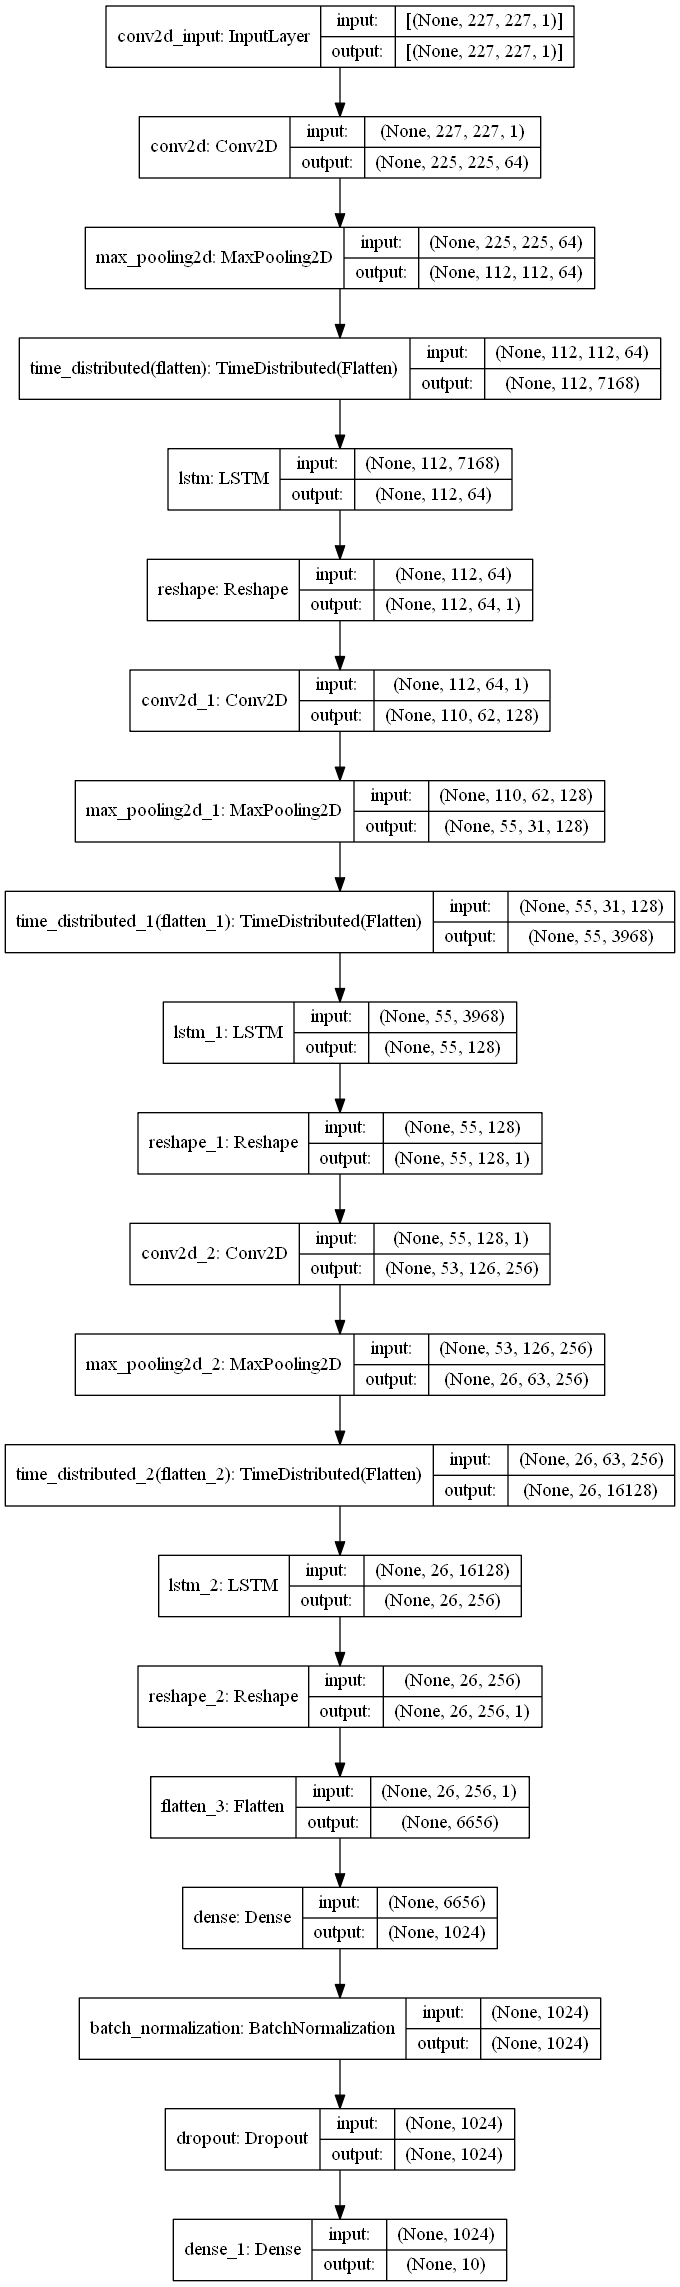

In [3]:
from keras.utils.vis_utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True)

In [4]:
from keras.preprocessing.image import ImageDataGenerator

In [5]:
def generator(dir, gen=image.ImageDataGenerator(rescale=1./511), shuffle=True,batch_size=1,target_size=(227,227),class_mode='categorical' ):

    return gen.flow_from_directory(dir,batch_size=batch_size,shuffle=shuffle,color_mode='grayscale',class_mode=class_mode,target_size=target_size)

BS= 32
TS=(227,227)
train_batch= generator('DATASET/Final/FINAL_2/train',shuffle=True, batch_size=BS,target_size=TS)
tr_SPE= len(train_batch.classes)//BS
print(tr_SPE)


tr_img,tr_labels= next(train_batch)

Found 1200 images belonging to 10 classes.
37


In [6]:
BS= 32
TS=(227,227)
test_batch= generator('DATASET/Final/FINAL_2/val',shuffle=True, batch_size=BS,target_size=TS)
te_SPE= len(test_batch.classes)//BS
print(te_SPE)


te_img,te_labels= next(test_batch)

Found 410 images belonging to 10 classes.
12


In [7]:
model.fit(x=train_batch,
    steps_per_epoch=tr_SPE,
    validation_data=test_batch,
    validation_steps=te_SPE,
    epochs=20,
    verbose=1
)

Epoch 1/20
37/37 [==============================] - 109s 3s/step - loss: 2.3029 - accuracy: 0.0899 - val_loss: 2.3028 - val_accuracy: 0.0911
Epoch 2/20
37/37 [==============================] - 119s 3s/step - loss: 2.3026 - accuracy: 0.0993 - val_loss: 2.3025 - val_accuracy: 0.0990
Epoch 3/20
37/37 [==============================] - 105s 3s/step - loss: 2.3022 - accuracy: 0.1233 - val_loss: 2.3024 - val_accuracy: 0.1016
Epoch 4/20
37/37 [==============================] - 110s 3s/step - loss: 2.3024 - accuracy: 0.0967 - val_loss: 2.3027 - val_accuracy: 0.1042
Epoch 5/20
37/37 [==============================] - 106s 3s/step - loss: 2.3023 - accuracy: 0.1139 - val_loss: 2.3025 - val_accuracy: 0.1042
Epoch 6/20
37/37 [==============================] - 116s 3s/step - loss: 2.3022 - accuracy: 0.1164 - val_loss: 2.3022 - val_accuracy: 0.1068
Epoch 7/20
37/37 [==============================] - 109s 3s/step - loss: 2.3013 - accuracy: 0.1139 - val_loss: 2.3026 - val_accuracy: 0.1016
Epoch 8/20
37

In [8]:
model.evaluate(x=train_batch)

38/38 [==============================] - 51s 1s/step - loss: 5.1433 - accuracy: 0.1942


[5.143326759338379, 0.1941666603088379]

In [9]:
model.evaluate(x=test_batch)

13/13 [==============================] - 13s 981ms/step - loss: 4.8918 - accuracy: 0.1951


[4.891817092895508, 0.19512194395065308]

In [10]:
y_test_pred=model.predict(test_batch)

In [11]:
y_test_pred[0]

array([4.5210618e-01, 5.0480360e-01, 1.5347380e-03, 1.1471884e-04,
       1.6694302e-02, 8.4103522e-04, 2.5729418e-03, 1.3319057e-02,
       7.7801626e-03, 2.3324133e-04], dtype=float32)